# AMS563 Homework 1 (Spring 2026) - Part C

This assignment is for AMS563, Spring 2026. Complete all tasks in this notebook. Keep the structure unchanged and run all cells before submission.


In [5]:
!pip install opencv-contrib-python==4.8.0.76

In [6]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [7]:
# Set your working directory (in your google drive)
#   change it to your specific homework directory.
%cd '/content/gdrive/My Drive/AMS563/AMS563-26S-HW1'

/content/gdrive/My Drive/AMS563/AMS563-26S-HW1


## Problem 3: Replacing Poster with a Painting (15pts)
#### Description
----
In this problem, you will replace a CEWIT poster in a scene image with a template image (i.e. a painting of aquarium), using homography transformation.

In [8]:
import numpy as np
import cv2 as cv
print(np.__version__)
print(cv.__version__)

1.26.4
4.9.0


In [9]:
# import packages here

import matplotlib.pyplot as plt

print(cv.__version__) # verify OpenCV version

# figure and show
def imshow(im, title=None):
    plt.figure(figsize=(18, 6))
    plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

4.9.0


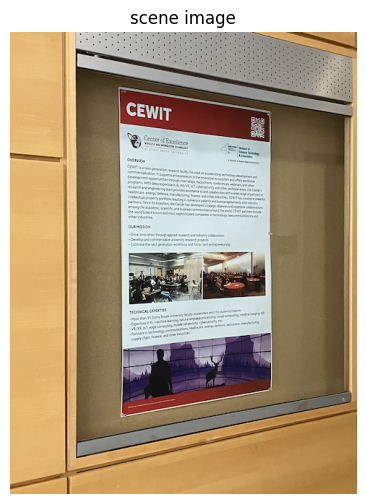

In [10]:
# read in the scene image and display
scene_img = cv.imread('SourceImages/poster.jpg')
imshow(scene_img, 'scene image')

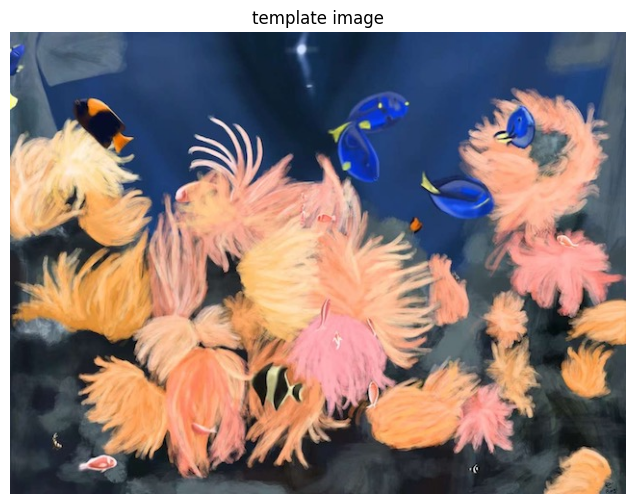

In [11]:
# read in the template image
template_img = cv.imread("SourceImages/painting.jpg")
imshow(template_img, 'template image')

### Part 1: select four points
(5 points) In this part, you need to provide the coordinates of the four corners of the CEWIT poster in the scene image.

You do not need to provide the process of how you get the coordinates. You can use whatever approach (including manual measure it in Photoshop).

The provided visualization codes will display your selection as red points, to help you verify your results.

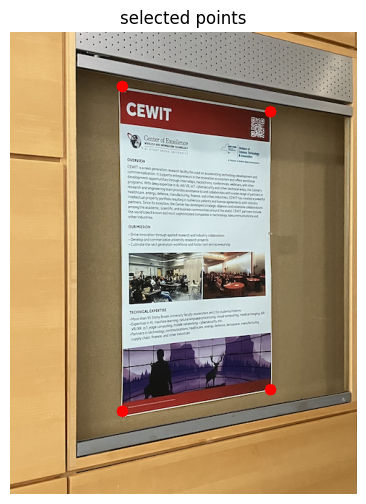

In [24]:
##########--WRITE YOUR CODE HERE--##########
select_pts = [
    (155, 75),   # top-left
    (360, 110),   # top-right
    (360, 495),  # bottom-right
    (155, 525)   # bottom-left
]

# visualize the selected four points in red
viz_img = scene_img.copy()
# print(viz_img.shape)
for i in range(4):
    viz_img = cv.circle(viz_img, select_pts[i], radius=8, color=(0, 0, 255), thickness=-1)
imshow(viz_img, 'selected points')


### Part 2: Estimate the homography
(15 points) In this part, you need to estimate the homography **from the scene image to the template image**.

In [25]:
# estimate the homography from the scene image to the template image geometry estimation
def estimate_homograph(sel_pts, temp_img):
    ##########--WRITE YOUR CODE HERE--##########
    # source points: corners in the scene image
    src_pts = np.array(sel_pts, dtype=np.float32)

    # destination points: corners of the template image
    h, w = temp_img.shape[:2]
    dst_pts = np.array([
        [0, 0],         # top-left
        [w - 1, 0],     # top-right
        [w - 1, h - 1], # bottom-right
        [0, h - 1]      # bottom-left
    ], dtype=np.float32)

    homo_matrix, _ = cv.findHomography(src_pts, dst_pts, method=0)
    ##########--WRITE YOUR CODE HERE--##########
    return homo_matrix

H = estimate_homograph(select_pts, template_img)
print(f"homograph matrix from scene image to template image: \n{H}")

homograph matrix from scene image to template image: 
[[ 2.40425116e+00 -1.08567727e-16 -3.72658930e+02]
 [-1.63840704e-01  9.59638407e-01 -4.65775715e+01]
 [-6.35230882e-04 -4.04984000e-19  1.00000000e+00]]


### Part 3: Replace the poster in the scene
(15 points) In this part, you need to replace the CEWIT poster in the scene image with the template painting, based on the homography matrix you have estimated in Part 2.

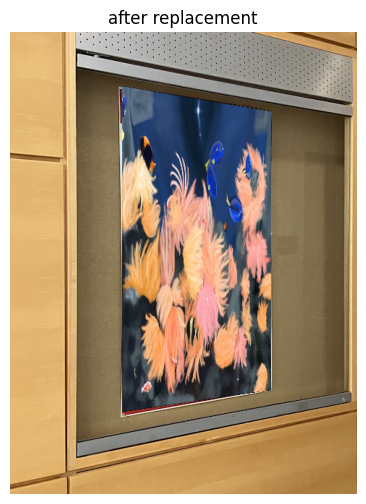

True

In [27]:
def replace(src_img, tgt_img, homo_matrix):
    # src_img: scene image (where the poster currently is)
    # tgt_img: template image (the painting to insert)

    h_scene, w_scene = src_img.shape[:2]

    # make sure template has 3 channels (BGR) to match the scene
    if len(tgt_img.shape) == 2:
        tgt_color = cv.cvtColor(tgt_img, cv.COLOR_GRAY2BGR)
    else:
        tgt_color = tgt_img.copy()

    # homo_matrix maps scene -> template, so invert it to map template -> scene
    H_inv = np.linalg.inv(homo_matrix)

    # warp the template into the scene geometry
    warped_tgt = cv.warpPerspective(tgt_color, H_inv, (w_scene, h_scene))

    # build a mask for the warped region (where the template lands)
    mask = np.ones((tgt_color.shape[0], tgt_color.shape[1]), dtype=np.uint8) * 255
    warped_mask = cv.warpPerspective(mask, H_inv, (w_scene, h_scene))

    # copy template pixels into the scene where mask is valid
    result = src_img.copy()
    result[warped_mask > 0] = warped_tgt[warped_mask > 0]

    return result

new_img = replace(scene_img, template_img, H)
imshow(new_img, 'after replacement')
cv.imwrite('result.png', new_img)